# Stage 2 – Task 3: Supervised Learning - Regression Pipeline

**Mục tiêu:** Dự đoán một giá trị số liên tục là **giá trị đơn hàng (`TotalAmount`)** và so sánh hai thuật toán **LinearRegression** và **DecisionTreeRegressor**.

Các bước chính (theo đúng đề bài Task 3):
1. Đọc dữ liệu từ `master_dataset_with_cluster_labels.csv` và khám phá nhanh.
2. Chọn đặc trưng (`X`) và biến mục tiêu (`y` = `TotalAmount`), chia train/test bằng `train_test_split`.
3. Huấn luyện và đánh giá **LinearRegression** bằng MSE, RMSE, $R^2$.
4. Huấn luyện và đánh giá **DecisionTreeRegressor**, kiểm tra overfitting.
5. Vẽ biểu đồ chẩn đoán: **Actual vs Predicted** và **Residual Plot**.
6. So sánh hai mô hình, chọn mô hình tốt nhất và lưu vào thư mục `model/`.

## 1. Import thư viện và đọc dữ liệu

Dùng các thư viện cơ bản: `pandas`, `numpy`, `matplotlib`, `seaborn` và các công cụ từ `scikit-learn`.

In [2]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

sns.set_style('whitegrid')
RANDOM_STATE = 42   # cố định số ngẫu nhiên để kết quả chạy lại luôn giống nhau

# Đọc file dataset (kết quả của Task 1-2, đã có cột Cluster_Label)
df = pd.read_csv('master_dataset_with_cluster_labels.csv')

print(f"Kích thước dữ liệu: {df.shape[0]} dòng, {df.shape[1]} cột")
display(df.head())

Kích thước dữ liệu: 1000 dòng, 25 cột


,OrderID,CustomerID,CustomerName,Age,Gender,City,ProductID,Quantity,TotalAmount,PurchaseDate,...,Rating,Source,Currency,Price_VND_ref,UnitPrice,Gender_Nữ,PaymentMethod_Thẻ ngân hàng,PaymentMethod_Tiền mặt,PaymentMethod_Ví điện tử,Cluster_Label
0,ORD00001,C0214,Nguyễn Quốc Khoa,37,Nam,Hải Phòng,P10412,3,57000,2026-01-01,...,4.88,Pharmacity_VN,VND,19000.0,19000.0,False,False,False,True,3
1,ORD00002,C0020,Trần Hữu Thành,18,Nam,Đà Nẵng,P18082,3,123000,2026-01-01,...,4.92,Pharmacity_VN,VND,41000.0,41000.0,False,True,False,False,4
2,ORD00003,C0144,Bùi Thị Xuân,32,Nữ,TP. Hồ Chí Minh,P29620,1,194250,2026-01-01,...,4.87,Pharmacity_VN,VND,194250.0,194250.0,True,False,True,False,4
3,ORD00004,C0253,Nguyễn Minh Huy,51,Nam,Hà Nội,P28349,1,110000,2026-01-02,...,4.85,Pharmacity_VN,VND,110000.0,110000.0,False,False,False,False,8
4,ORD00005,C0138,Nguyễn Mỹ Dương,27,Nữ,Cần Thơ,P25083,3,37500,2026-01-02,...,4.96,Pharmacity_VN,VND,12500.0,12500.0,True,False,True,False,2


## 2. Khám phá nhanh dữ liệu

Trước khi xây mô hình, ta kiểm tra dữ liệu thiếu, xem phân bố của biến mục tiêu `TotalAmount` và mức độ tương quan giữa các cột số.

### ⚠️ Lưu ý: `TotalAmount = UnitPrice × Quantity`
Biến mục tiêu được tính trực tiếp từ hai đặc trưng `UnitPrice` và `Quantity`. Vì vậy mô hình có thể đạt điểm cao một cách "dễ dàng" nếu nó học được phép nhân này. Đây cũng là lý do ta so sánh hai mô hình: **Linear Regression chỉ học được quan hệ cộng**, còn **Decision Tree có thể xấp xỉ quan hệ nhân** nhờ chia nhánh.

In [3]:
features = ['Age', 'UnitPrice', 'Quantity', 'Rating']
target = 'TotalAmount'

print("Số giá trị thiếu trong các cột được chọn:")
print(df[features + [target]].isna().sum())
print()
print("Thống kê mô tả:")
display(df[features + [target]].describe().round(2))

Số giá trị thiếu trong các cột được chọn:
Age            0
UnitPrice      0
Quantity       0
Rating         0
TotalAmount    0
dtype: int64

Thống kê mô tả:


,Age,UnitPrice,Quantity,Rating,TotalAmount
count,1000.00,1000.00,1000.00,1000.00,1000.00
mean,30.44,90244.90,1.89,4.76,170544.70
std,8.99,69849.77,1.10,0.15,183958.22
min,18.00,10000.00,1.00,4.50,10000.00
25%,23.00,38000.00,1.00,4.63,57000.00
50%,30.00,68000.00,1.50,4.77,110000.00
75%,36.00,119000.00,3.00,4.88,199000.00
max,69.00,399200.00,5.00,5.00,1225000.00


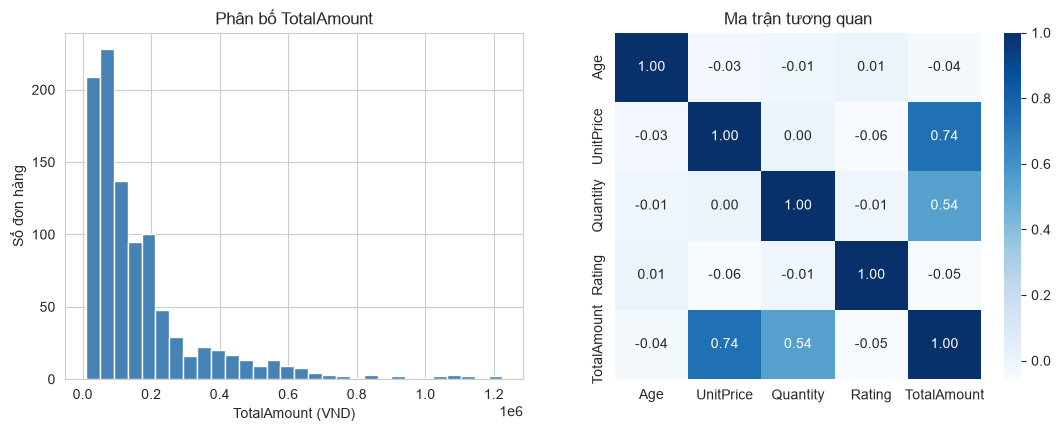

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# (1) Phân bố của biến mục tiêu
axes[0].hist(df[target], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Phân bố TotalAmount')
axes[0].set_xlabel('TotalAmount (VND)')
axes[0].set_ylabel('Số đơn hàng')

# (2) Ma trận tương quan giữa các cột số
corr = df[features + [target]].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='Blues', ax=axes[1])
axes[1].set_title('Ma trận tương quan')


plt.show()

**Nhận xét:**
- Các cột được chọn không có giá trị thiếu nên có thể dùng trực tiếp.
- `TotalAmount` **lệch phải**: đa số đơn có giá trị thấp đến trung bình, chỉ một số ít đơn rất lớn (tối đa hơn 1,2 triệu VND). Các đơn lớn này thường là những đơn khó dự đoán nhất.
- `TotalAmount` tương quan mạnh nhất với `UnitPrice` (khoảng 0,74) rồi đến `Quantity` (khoảng 0,54). `Age` và `Rating` gần như không tương quan (khoảng -0,04 và -0,05).

## 3. Chọn đặc trưng và chia Train / Test

- **Đặc trưng (X):** `Age`, `UnitPrice`, `Quantity`, `Rating`.
- **Mục tiêu (y):** `TotalAmount` (giá trị số liên tục).
- Chia 80% dữ liệu để huấn luyện, 20% để kiểm tra, để đánh giá mô hình trên dữ liệu mà nó chưa từng thấy.

Ngoài ra, ta tính thêm một **mô hình cơ sở (baseline)**: luôn dự đoán bằng giá trị trung bình của tập train. Mọi mô hình có ý nghĩa đều phải tốt hơn baseline này.

In [5]:
X = df[features]
y = df[target]

# Chia tập train/test (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

print(f"Số lượng tập train: {X_train.shape[0]} dòng")
print(f"Số lượng tập test: {X_test.shape[0]} dòng")

Số lượng tập train: 800 dòng
Số lượng tập test: 200 dòng


In [6]:
# Baseline: luôn dự đoán bằng trung bình của tập train
baseline_value = y_train.mean()
baseline_pred = [baseline_value] * len(y_test)

baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
baseline_r2 = r2_score(y_test, baseline_pred)

print("KẾT QUẢ BASELINE (luôn đoán bằng giá trị trung bình)")
print(f"Giá trị trung bình = {baseline_value:,.0f} VND")
print(f"RMSE = {baseline_rmse:,.2f}")
print(f"R²   = {baseline_r2:.4f}")

KẾT QUẢ BASELINE (luôn đoán bằng giá trị trung bình)
Giá trị trung bình = 164,925 VND
RMSE = 198,665.55
R²   = -0.0204


## 4. Mô hình 1: Linear Regression

Hồi quy tuyến tính tìm một công thức dạng `TotalAmount = a1×Age + a2×UnitPrice + a3×Quantity + a4×Rating + b` sao cho sai số nhỏ nhất. Đây là mô hình cơ sở dễ giải thích.

In [7]:
# Khởi tạo và huấn luyện mô hình Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Dự đoán trên tập train và tập test
lr_pred_train = lr_model.predict(X_train)
lr_pred = lr_model.predict(X_test)

# Tính các chỉ số đánh giá trên tập test
lr_mse = mean_squared_error(y_test, lr_pred)
lr_rmse = np.sqrt(lr_mse)
lr_r2 = r2_score(y_test, lr_pred)
lr_r2_train = r2_score(y_train, lr_pred_train)

print("KẾT QUẢ LINEAR REGRESSION")
print(f"MSE  = {lr_mse:.2f}")
print(f"RMSE = {lr_rmse:.2f}")
print(f"R² (Test)  = {lr_r2:.4f}")
print(f"R² (Train) = {lr_r2_train:.4f}")

KẾT QUẢ LINEAR REGRESSION
MSE  = 5609457039.56
RMSE = 74896.31
R² (Test)  = 0.8550
R² (Train) = 0.8251


In [8]:
# Xem hệ số của từng đặc trưng
coef_table = pd.DataFrame({'Đặc trưng': features, 'Hệ số': lr_model.coef_})
display(coef_table.round(2))
print(f"Hệ số chặn (intercept) = {lr_model.intercept_:,.2f}")

,Đặc trưng,Hệ số
0,Age,4.33
1,UnitPrice,1.91
2,Quantity,89286.41
3,Rating,1159.49


Hệ số chặn (intercept) = -177,102.19


### Nhận xét Linear Regression
- RMSE khoảng 75 nghìn VND: mỗi đơn dự đoán lệch trung bình cỡ đó, khá lớn so với giá trị đơn trung bình (khoảng 170 nghìn VND).
- Theo bảng hệ số, `Quantity` có ảnh hưởng lớn nhất (mỗi sản phẩm mua thêm làm `TotalAmount` tăng khoảng 89 nghìn VND), còn `Age` và `Rating` có hệ số rất nhỏ, gần như không đóng góp.
- $R^2$ Train (≈ 0,83) và $R^2$ Test (≈ 0,85) gần nhau nên mô hình **không bị overfitting**. Hạn chế của nó là do mô hình tuyến tính chỉ cộng các đặc trưng lại, không mô tả được phép **nhân** `UnitPrice × Quantity`.

## 5. Mô hình 2: Decision Tree Regressor

Cây quyết định chia dữ liệu thành các nhánh theo điều kiện (ví dụ: `UnitPrice > 100000?`, `Quantity > 2?`), nên có thể nắm bắt được các quan hệ phi tuyến mà mô hình tuyến tính bỏ sót. Ở đây ta để cây phát triển tự do (không giới hạn độ sâu).

In [9]:
# Khởi tạo và huấn luyện mô hình Decision Tree Regressor
dt_model = DecisionTreeRegressor(random_state=RANDOM_STATE)
dt_model.fit(X_train, y_train)

# Dự đoán trên tập train và tập test
dt_pred_train = dt_model.predict(X_train)
dt_pred = dt_model.predict(X_test)

# Tính các chỉ số đánh giá trên tập test
dt_mse = mean_squared_error(y_test, dt_pred)
dt_rmse = np.sqrt(dt_mse)
dt_r2 = r2_score(y_test, dt_pred)
dt_r2_train = r2_score(y_train, dt_pred_train)

print("KẾT QUẢ DECISION TREE REGRESSOR")
print(f"MSE  = {dt_mse:.2f}")
print(f"RMSE = {dt_rmse:.2f}")
print(f"R² (Test)  = {dt_r2:.4f}")
print(f"R² (Train) = {dt_r2_train:.4f}")
print(f"Độ sâu của cây = {dt_model.get_depth()}")

KẾT QUẢ DECISION TREE REGRESSOR
MSE  = 883023363.12
RMSE = 29715.71
R² (Test)  = 0.9772
R² (Train) = 1.0000
Độ sâu của cây = 12


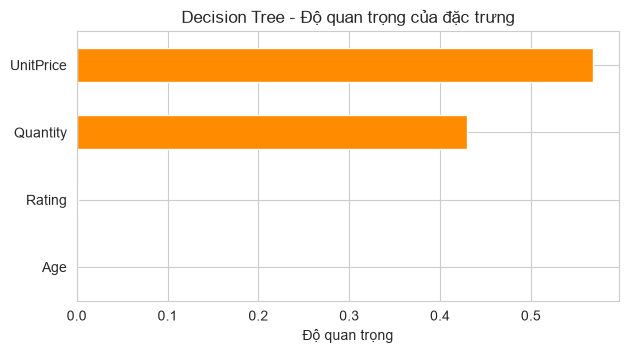

UnitPrice    0.569
Quantity     0.429
Rating       0.002
Age          0.000
dtype: float64


In [10]:
# Độ quan trọng của từng đặc trưng trong cây
importance = pd.Series(dt_model.feature_importances_, index=features).sort_values()

plt.figure(figsize=(7, 3.5))
importance.plot(kind='barh', color='darkorange')
plt.title('Decision Tree - Độ quan trọng của đặc trưng')
plt.xlabel('Độ quan trọng')
plt.show()

print(importance.sort_values(ascending=False).round(3))

### Nhận xét Decision Tree Regressor
- $R^2$ Test ≈ 0,98 và RMSE ≈ 29,7 nghìn VND: sai số giảm hơn một nửa so với Linear Regression, vì cây chia nhánh theo `UnitPrice` và `Quantity` nên xấp xỉ được quan hệ phi tuyến.
- $R^2$ Train = 1,0 trong khi $R^2$ Test ≈ 0,98: cây đã "học thuộc" tập train, có chênh lệch nhỏ (overfitting nhẹ) nhưng điểm trên tập test vẫn rất cao.
- Theo biểu đồ độ quan trọng, `UnitPrice` (≈ 0,57) và `Quantity` (≈ 0,43) chiếm gần như toàn bộ; `Rating` và `Age` gần bằng 0. Nghĩa là cây chủ yếu học lại quy luật `UnitPrice × Quantity`.

## 6. Thử nghiệm độ sâu của cây (kiểm tra overfitting)

Cây không giới hạn độ sâu rất dễ "học thuộc" dữ liệu train. Ta thử nhiều giá trị `max_depth` khác nhau và so sánh $R^2$ trên tập train với tập test. Nếu hai đường tách xa nhau thì mô hình đang bị overfitting.

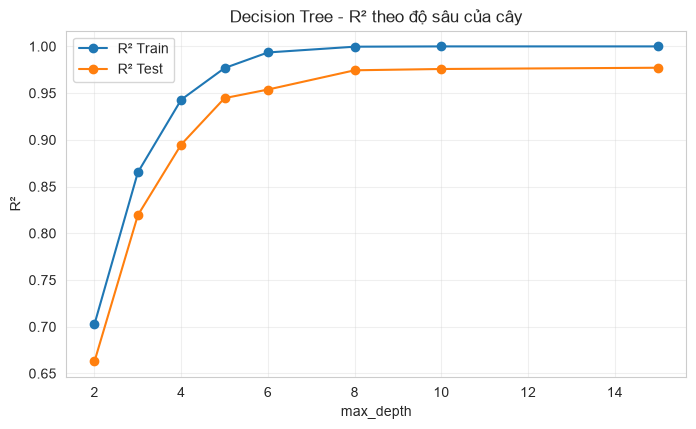

,max_depth,R² Train,R² Test
0,2,0.7028,0.6629
1,3,0.8652,0.8193
2,4,0.9430,0.8950
3,5,0.9768,0.9446
4,6,0.9935,0.9538
5,8,0.9997,0.9744
6,10,1.0000,0.9758
7,15,1.0000,0.9772


In [11]:
depths = [2, 3, 4, 5, 6, 8, 10, 15]
train_r2_list = []
test_r2_list = []

for d in depths:
    tree = DecisionTreeRegressor(max_depth=d, random_state=RANDOM_STATE)
    tree.fit(X_train, y_train)
    train_r2_list.append(r2_score(y_train, tree.predict(X_train)))
    test_r2_list.append(r2_score(y_test, tree.predict(X_test)))

plt.figure(figsize=(8, 4.5))
plt.plot(depths, train_r2_list, marker='o', label='R² Train')
plt.plot(depths, test_r2_list, marker='o', label='R² Test')
plt.xlabel('max_depth')
plt.ylabel('R²')
plt.title('Decision Tree - R² theo độ sâu của cây')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

depth_table = pd.DataFrame({'max_depth': depths, 'R² Train': train_r2_list, 'R² Test': test_r2_list})
display(depth_table.round(4))

### Nhận xét
- Khi tăng `max_depth`, $R^2$ Train tăng nhanh đến 1,0 còn $R^2$ Test tăng chậm dần rồi gần như dừng (khoảng 0,97 từ độ sâu 8 trở đi). $R^2$ Test **không giảm** khi cây sâu hơn.
- Với bộ dữ liệu này cây không giới hạn độ sâu vẫn ổn, vì `TotalAmount` là một hàm xác định của `UnitPrice` và `Quantity` nên cây càng sâu càng xấp xỉ tốt. Với dữ liệu thật có nhiều nhiễu thì cây sâu thường bị overfitting, lúc đó nên giới hạn `max_depth`.
- Nếu muốn một cây đơn giản, dễ giải thích hơn, `max_depth = 5` đã cho $R^2$ Test khoảng 0,94.

## 7. Trực quan hóa: Actual vs Predicted

Mỗi điểm là một đơn hàng trong tập test: trục ngang là giá trị **thực tế**, trục dọc là giá trị **mô hình dự đoán**. Các điểm nằm càng sát đường chéo lý tưởng ($y = x$) thì dự đoán càng chính xác.

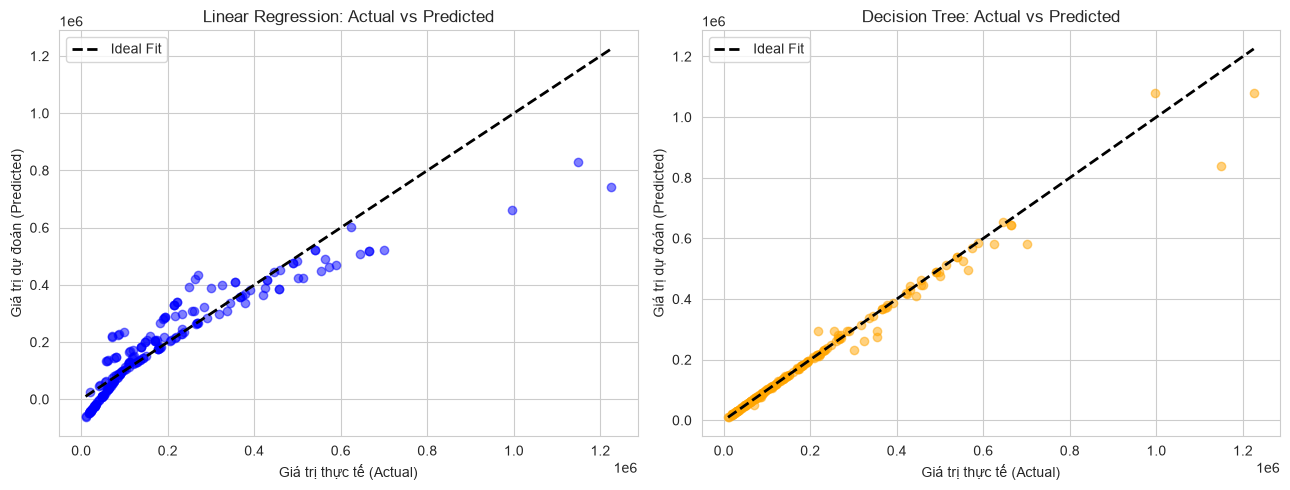

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
line_min = y_test.min()
line_max = y_test.max()

axes[0].scatter(y_test, lr_pred, color='blue', alpha=0.5)
axes[0].plot([line_min, line_max], [line_min, line_max], 'k--', lw=2, label='Ideal Fit')
axes[0].set_title('Linear Regression: Actual vs Predicted')
axes[0].set_xlabel('Giá trị thực tế (Actual)')
axes[0].set_ylabel('Giá trị dự đoán (Predicted)')
axes[0].legend()

axes[1].scatter(y_test, dt_pred, color='orange', alpha=0.5)
axes[1].plot([line_min, line_max], [line_min, line_max], 'k--', lw=2, label='Ideal Fit')
axes[1].set_title('Decision Tree: Actual vs Predicted')
axes[1].set_xlabel('Giá trị thực tế (Actual)')
axes[1].set_ylabel('Giá trị dự đoán (Predicted)')
axes[1].legend()

plt.tight_layout()
plt.show()

### Nhận xét
- **Linear Regression:** các điểm phân tán khá xa đường chéo, nhất là với đơn giá trị lớn. Mô hình còn dự đoán ra **giá trị âm** cho một số đơn, điều không hợp lý vì mọi đơn đều có giá trị từ 10.000 VND trở lên.
- **Decision Tree:** phần lớn các điểm nằm sát đường chéo, chỉ lệch ở một vài đơn có giá trị rất lớn.

## 8. Residual Plot (biểu đồ phần dư)

**Phần dư (residual) = giá trị thực tế − giá trị dự đoán.** Nếu mô hình tốt, các điểm phải nằm rải ngẫu nhiên quanh đường $0$. Nếu thấy hình cong, hình phễu hoặc lệch hẳn về một phía thì mô hình đang mắc **sai số có hệ thống** (systematic error).

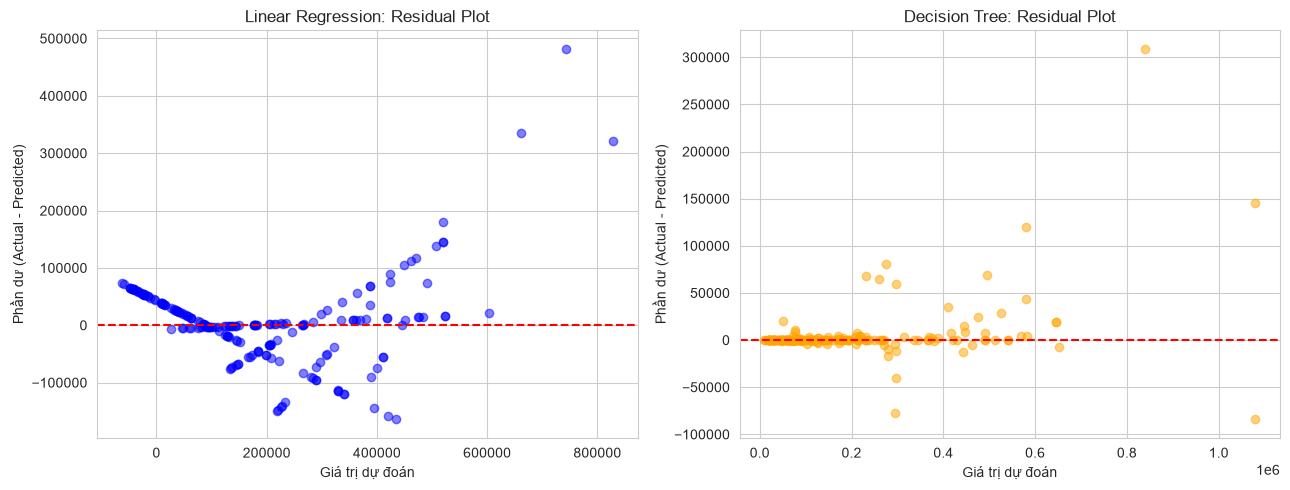

Số dự đoán ÂM của Linear Regression: 28 / 200 đơn
Phần dư trung bình - Linear Regression: 5,103
Phần dư trung bình - Decision Tree    : 4,675


In [13]:
lr_residual = y_test - lr_pred
dt_residual = y_test - dt_pred

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(lr_pred, lr_residual, color='blue', alpha=0.5)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title('Linear Regression: Residual Plot')
axes[0].set_xlabel('Giá trị dự đoán')
axes[0].set_ylabel('Phần dư (Actual - Predicted)')

axes[1].scatter(dt_pred, dt_residual, color='orange', alpha=0.5)
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title('Decision Tree: Residual Plot')
axes[1].set_xlabel('Giá trị dự đoán')
axes[1].set_ylabel('Phần dư (Actual - Predicted)')

plt.tight_layout()
plt.show()

print(f"Số dự đoán ÂM của Linear Regression: {(lr_pred < 0).sum()} / {len(lr_pred)} đơn")
print(f"Phần dư trung bình - Linear Regression: {lr_residual.mean():,.0f}")
print(f"Phần dư trung bình - Decision Tree    : {dt_residual.mean():,.0f}")

### Nhận xét Residual Plot
- **Linear Regression:** phần dư **không rải ngẫu nhiên** mà tạo thành đường cong rõ rệt quanh đường 0 (dương ở vùng dự đoán thấp và rất cao, âm ở vùng giữa). Đây là dấu hiệu của **sai số có hệ thống**: mô hình tuyến tính không phù hợp với quan hệ nhân giữa `UnitPrice` và `Quantity`. Các dự đoán âm ở ô bên trên cũng nằm trong nhóm lỗi này.
- **Decision Tree:** phần lớn phần dư tập trung sát đường 0. Một số ít điểm lệch lớn nằm ở vùng giá trị cao, nơi có ít dữ liệu nên cây dự đoán kém chính xác hơn.
- Phần dư trung bình của cả hai mô hình đều dương nhỏ (khoảng 5 nghìn VND), tức là mô hình đoán thấp hơn thực tế một chút.

## 9. Bảng so sánh tổng hợp hai mô hình

Gộp kết quả của baseline và hai mô hình vào một bảng để dễ so sánh. Mô hình tốt hơn có **MSE, RMSE thấp hơn** và **$R^2$ cao hơn**.

,Mô hình,MSE,RMSE,R2 (Test),R2 (Train)
0,Baseline (trung bình),3.946800e+10,198665.5549,-0.0204,NaN
1,LinearRegression,5.609457e+09,74896.3086,0.8550,0.8251
2,DecisionTreeRegressor,8.830234e+08,29715.7090,0.9772,1.0000


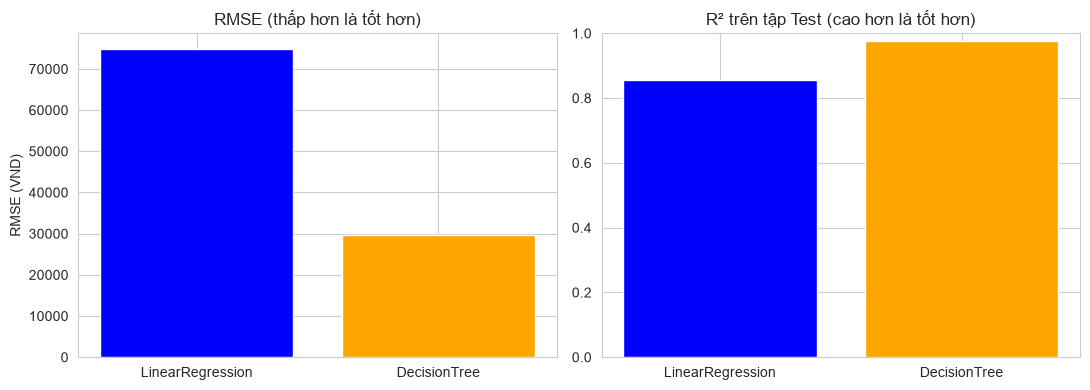

In [14]:
ket_qua = pd.DataFrame({
    'Mô hình': ['Baseline (trung bình)', 'LinearRegression', 'DecisionTreeRegressor'],
    'MSE': [baseline_rmse ** 2, lr_mse, dt_mse],
    'RMSE': [baseline_rmse, lr_rmse, dt_rmse],
    'R2 (Test)': [baseline_r2, lr_r2, dt_r2],
    'R2 (Train)': [np.nan, lr_r2_train, dt_r2_train]
})
display(ket_qua.round(4))

# Biểu đồ cột so sánh RMSE và R² giữa hai mô hình
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
names = ['LinearRegression', 'DecisionTree']

axes[0].bar(names, [lr_rmse, dt_rmse], color=['blue', 'orange'])
axes[0].set_title('RMSE (thấp hơn là tốt hơn)')
axes[0].set_ylabel('RMSE (VND)')

axes[1].bar(names, [lr_r2, dt_r2], color=['blue', 'orange'])
axes[1].set_title('R² trên tập Test (cao hơn là tốt hơn)')
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

In [15]:
# Xem thử 10 đơn hàng trong tập test: giá trị thực tế và dự đoán của hai mô hình
mau = pd.DataFrame({
    'Thực tế': y_test.values,
    'Linear Regression': lr_pred.round(0),
    'Decision Tree': dt_pred.round(0)
})
display(mau.head(10))

,Thực tế,Linear Regression,Decision Tree
0,194400,289369.0,194400.0
1,98600,101270.0,98560.0
2,62500,37120.0,62500.0
3,445000,445333.0,410000.0
4,215000,328928.0,215000.0
5,22000,-40064.0,22000.0
6,232000,228992.0,232000.0
7,456000,386756.0,461700.0
8,60000,32554.0,60000.0
9,147200,199045.0,147000.0


## 10. Lưu mô hình tốt nhất vào thư mục `model/`

Chọn mô hình có $R^2$ cao hơn trên tập test, xuất ra file `.pkl` bằng `joblib` (file này được dùng cho Task 5 – giao diện Streamlit).

In [16]:
os.makedirs('model', exist_ok=True)
model_path = 'model/regression_model.pkl'

# Lưu mô hình có R² cao hơn
if dt_r2 > lr_r2:
    best_model = dt_model
    best_name = 'DecisionTreeRegressor'
else:
    best_model = lr_model
    best_name = 'LinearRegression'

joblib.dump(best_model, model_path)
print(f"Mô hình tốt nhất: {best_name}")
print(f"Đã lưu mô hình thành công tại: {model_path}")

# Kiểm tra: load lại file và dự đoán thử 1 đơn hàng mẫu
loaded_model = joblib.load(model_path)
sample = pd.DataFrame([[30, 150000, 2, 4.8]], columns=features)
print(f"Đơn mẫu (Age=30, UnitPrice=150,000, Quantity=2, Rating=4.8) -> dự đoán TotalAmount = {loaded_model.predict(sample)[0]:,.0f} VND")

Mô hình tốt nhất: DecisionTreeRegressor
Đã lưu mô hình thành công tại: model/regression_model.pkl
Đơn mẫu (Age=30, UnitPrice=150,000, Quantity=2, Rating=4.8) -> dự đoán TotalAmount = 298,000 VND


In [17]:
print("TỔNG KẾT TASK 3")
print(f"- Baseline          : RMSE = {baseline_rmse:,.0f} | R² = {baseline_r2:.3f}")
print(f"- LinearRegression  : RMSE = {lr_rmse:,.0f} | R² = {lr_r2:.3f}")
print(f"- DecisionTree      : RMSE = {dt_rmse:,.0f} | R² = {dt_r2:.3f}")
print(f">>> Mô hình thắng: {best_name}")

TỔNG KẾT TASK 3
- Baseline          : RMSE = 198,666 | R² = -0.020
- LinearRegression  : RMSE = 74,896 | R² = 0.855
- DecisionTree      : RMSE = 29,716 | R² = 0.977
>>> Mô hình thắng: DecisionTreeRegressor


## 11. Kết luận Task 3

**Mô hình thắng: `DecisionTreeRegressor`.** Mô hình này tốt hơn Linear Regression ở cả ba chỉ số: MSE và RMSE thấp hơn (RMSE khoảng 29,7 nghìn so với 74,9 nghìn VND) và $R^2$ cao hơn (khoảng 0,98 so với 0,85). Biểu đồ Actual vs Predicted và Residual Plot cũng cho thấy cây ít sai số hệ thống hơn. Mô hình này được lưu vào `model/regression_model.pkl` để dùng cho Task 5.

**Hạn chế cần nêu trong báo cáo:**
1. `TotalAmount = UnitPrice × Quantity`, nên điểm cao một phần vì mô hình học lại công thức này. Không nên diễn giải đây là khả năng "dự đoán hành vi khách hàng".
2. `Age` và `Rating` gần như không ảnh hưởng đến giá trị đơn trong dữ liệu này.
3. Các đơn có giá trị rất lớn vẫn có sai số cao hơn, vì có ít mẫu.
4. Dữ liệu chỉ có 1000 đơn mô phỏng, cần kiểm tra lại trên dữ liệu thật.

**Gợi ý kinh doanh (dựa trên kết quả mô hình):**
1. Giá trị đơn gần như hoàn toàn do **đơn giá và số lượng** (độ quan trọng ≈ 0,57 và 0,43), nên có thể thiết kế ưu đãi combo hoặc "mua 2 giảm giá" cho nhóm sản phẩm giá cao để tăng số lượng mỗi đơn.
2. `Age` và `Rating` không giúp dự đoán giá trị đơn, nên việc nhắm ưu đãi theo giá trị đơn nên dựa vào **sản phẩm** hơn là độ tuổi.
3. Có thể dùng mô hình trong app Streamlit (Task 5) để ước tính nhanh doanh thu của một đơn khi biết đơn giá và số lượng dự kiến; riêng các đơn trên khoảng 400 nghìn VND cần xem xét thêm vì sai số cao hơn.